### 1.8 Tapering in Filtering: Edge Effects and Ringing

Filtering can create artifacts near the **edges** of a time series. These artifacts are often called **ringing**.

The basic issue is simple:

- our signal is finite in time
- the signal may not start and end smoothly
- filtering reacts strongly to these sharp edges

If we taper the data before filtering, we reduce the discontinuity at the boundaries and the filtered result is usually much cleaner.

In this section, we will first use a **very simple example** to make the effect obvious, and then we will look at a slightly more realistic signal.

#### 1.8.1 A Minimal Example

We start with a clean 5 Hz sine wave, but we force the first and last samples to have large values.

This creates an artificial discontinuity at the edges.

Then we apply the same bandpass filter in two ways:

1. **without tapering**
2. **with tapering**

The only difference is whether we smooth the signal to zero at the ends before filtering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, windows

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.size': 12,
    'lines.linewidth': 2,
})

sampling_rate = 100.0
dt = 1 / sampling_rate
t = np.arange(0, 2.0, dt)

x_clean = np.sin(2 * np.pi * 5 * t)

x_edge = x_clean.copy()
x_edge[0] = 2.0
x_edge[-1] = -2.0

b, a = butter(4, [4, 6], btype='band', fs=sampling_rate)

x_notaper = filtfilt(b, a, x_edge)

taper = windows.tukey(len(x_edge), alpha=0.2)
x_tapered_input = x_edge * taper
x_withtaper = filtfilt(b, a, x_tapered_input)

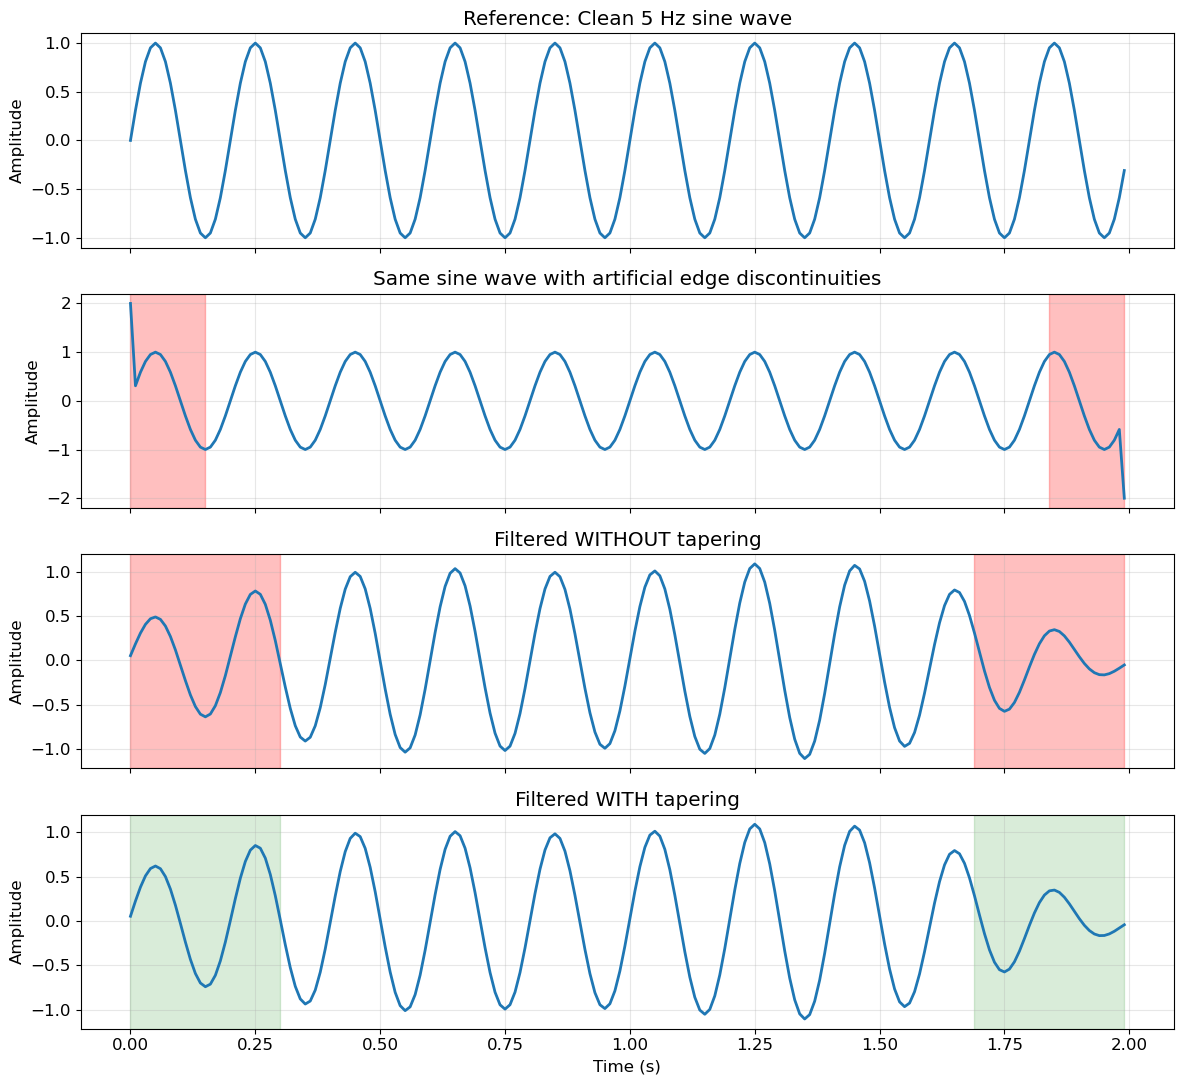

In [2]:
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

axes[0].plot(t, x_clean)
axes[0].set_title("Reference: Clean 5 Hz sine wave")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, x_edge)
axes[1].axvspan(0, 0.15, alpha=0.25, color='red')
axes[1].axvspan(t[-1]-0.15, t[-1], alpha=0.25, color='red')
axes[1].set_title("Same sine wave with artificial edge discontinuities")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, x_notaper)
axes[2].axvspan(0, 0.3, alpha=0.25, color='red')
axes[2].axvspan(t[-1]-0.3, t[-1], alpha=0.25, color='red')
axes[2].set_title("Filtered WITHOUT tapering")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)

axes[3].plot(t, x_withtaper)
axes[3].axvspan(0, 0.3, alpha=0.15, color='green')
axes[3].axvspan(t[-1]-0.3, t[-1], alpha=0.15, color='green')
axes[3].set_title("Filtered WITH tapering")
axes[3].set_ylabel("Amplitude")
axes[3].set_xlabel("Time (s)")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### What to notice

In the **third panel**, the filter responds to the sharp jump at the edges by creating oscillations. These oscillations are not part of the original signal.

In the **fourth panel**, tapering reduces the edge discontinuity before filtering, so the output is much cleaner.

> The ringing is not physical. It is created by the combination of sharp edges and filtering.

In [3]:
print("Maximum absolute amplitude near the left edge:")
print(f"  without taper = {np.max(np.abs(x_notaper[:25])):.3f}")
print(f"  with taper    = {np.max(np.abs(x_withtaper[:25])):.3f}")

print("\nMaximum absolute amplitude near the right edge:")
print(f"  without taper = {np.max(np.abs(x_notaper[-25:])):.3f}")
print(f"  with taper    = {np.max(np.abs(x_withtaper[-25:])):.3f}")

Maximum absolute amplitude near the left edge:
  without taper = 0.743
  with taper    = 0.798

Maximum absolute amplitude near the right edge:
  without taper = 0.572
  with taper    = 0.574


#### 1.8.2 A More Realistic Example

Now let's use a signal with several components:

- a large low-frequency component
- a 5 Hz component that we want to keep
- a higher-frequency component
- a DC offset

We then apply a **4-6 Hz bandpass filter**. The main signal we want to preserve is the 5 Hz part.

In [4]:
t2 = np.arange(0, 3.0, 1 / sampling_rate)

x_realistic = (
    1.5 * np.sin(2 * np.pi * 0.5 * t2) +
    1.0 * np.sin(2 * np.pi * 2.0 * t2) +
    0.8 * np.sin(2 * np.pi * 5.0 * t2) +
    0.3 * np.sin(2 * np.pi * 10.0 * t2) +
    0.8
)

taper2 = windows.tukey(len(x_realistic), alpha=0.2)

x_realistic_notaper = filtfilt(b, a, x_realistic)
x_realistic_tapered_input = x_realistic * taper2
x_realistic_withtaper = filtfilt(b, a, x_realistic_tapered_input)

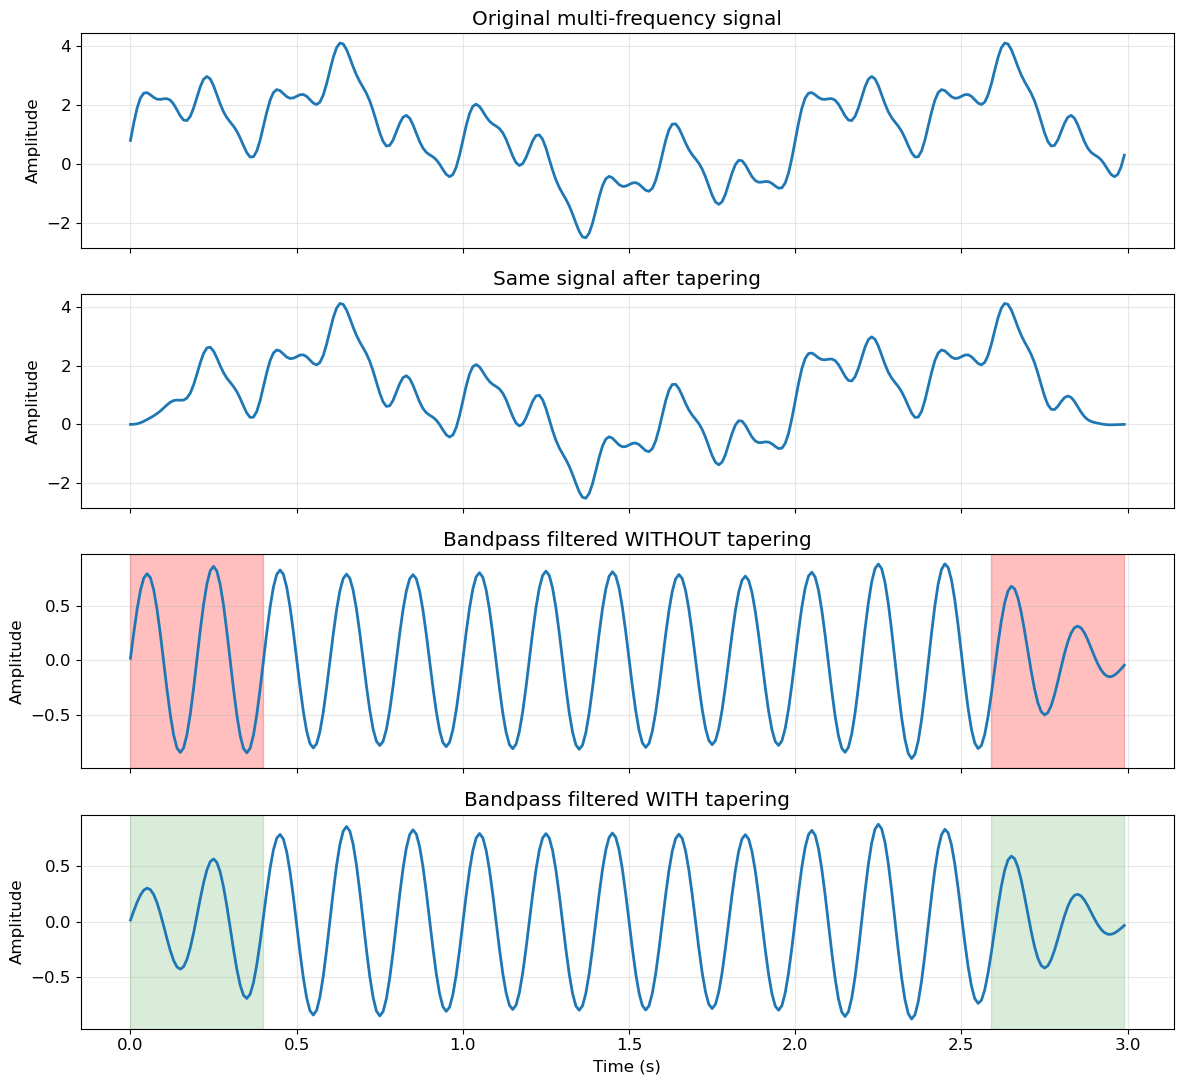

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

axes[0].plot(t2, x_realistic)
axes[0].set_title("Original multi-frequency signal")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t2, x_realistic_tapered_input)
axes[1].set_title("Same signal after tapering")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

axes[2].plot(t2, x_realistic_notaper)
axes[2].axvspan(0, 0.4, alpha=0.25, color='red')
axes[2].axvspan(t2[-1]-0.4, t2[-1], alpha=0.25, color='red')
axes[2].set_title("Bandpass filtered WITHOUT tapering")
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)

axes[3].plot(t2, x_realistic_withtaper)
axes[3].axvspan(0, 0.4, alpha=0.15, color='green')
axes[3].axvspan(t2[-1]-0.4, t2[-1], alpha=0.15, color='green')
axes[3].set_title("Bandpass filtered WITH tapering")
axes[3].set_ylabel("Amplitude")
axes[3].set_xlabel("Time (s)")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### What to notice here

This example is more realistic, so the effect is subtler than in the minimal example.

Focus on the **edges** of the filtered traces:

- without tapering, the boundaries are less trustworthy
- with tapering, the filtered signal transitions more smoothly to zero

The middle of the record is usually much less affected than the ends.

> In practice, tapering is mainly about making the boundaries behave well before filtering.

#### Key Takeaway

Tapering does not add information. It reduces artificial discontinuities at the start and end of the record.

This helps prevent the filter from generating **edge artifacts** that can look like real oscillations.

In real data analysis, tapering is a simple but important step before filtering.